### Name: Faraz Doagoye Tehrani
### Student ID: 402105998
### Designed by: Danial Parnian

# Homework: Advanced Inference & Reasoning for Tiny LLMs

In this homework, you will run a tiny open-source LLM on a small subset of **GSM8K** and compare several inference-time reasoning strategies:

1. Direct answer, `/no_think`
2. Chain-of-thought, `/no_think`
3. Chain-of-thought, `/think`
4. Self-consistency with `N = 5`
5. Few-shot prompting with `k = 1`
6. Self-refinement

The goal is not to train a model. The goal is to understand how much we can improve, or fail to improve, a small LLM by changing the way we ask it to reason and decode.

We will use **Qwen/Qwen3-0.6B** by default. It is small enough for Colab/Kaggle and supports both thinking and non-thinking behavior.

---

## What you submit

By the end of the notebook, you should have:

- A cleaned file called `gsm8k_64_clean.json`
- Per-method prediction files, such as `predictions_direct_no_think.csv`
- A summary file called `summary_results.csv`
- A final results table
- At least one plot: **accuracy vs average generated tokens**
- A short written discussion of your findings

---

## Grading rubric: 100 points

The setup, model loading, batched generation helper, and plotting template are mostly provided so the grading focuses on the reasoning experiment itself. Keep the provided function names and output filenames so your results are easy to check.

| Section | Points |
|---|---:|
| Reproducibility and clean execution: runs end-to-end, uses the fixed seed, keeps `NUM_SAMPLES = 64`, and uses a sensible `BATCH_SIZE` | 5 |
| Clean raw GSM8K: load `gsm8k_test.json`, sample 64 rows, extract `final_answer`, and save `gsm8k_64_clean.json` | 15 |
| Evaluation logic: model-answer extraction, correctness checking, invalid-rate handling, and unified metrics | 15 |
| Standard prompting methods: Direct `/no_think`, CoT `/no_think`, CoT `/think`, and Few-shot `k = 1` | 22 |
| Self-consistency with `N = 5`: sampled generations, answer extraction for each sample, majority vote, and correct token/latency accounting | 15 |
| Self-refinement: initial answer, revision prompt, final-answer extraction, and combined token/latency accounting | 10 |
| Results reporting: per-method prediction files, `summary_results.csv`, final table, and accuracy-vs-token plot | 10 |
| Short written analysis and one meaningful failure case | 8 |

The **22 points for standard prompting methods** are allocated as follows:

| Prompting method item | Points |
|---|---:|
| Direct `/no_think` | 4 |
| CoT `/no_think` | 5 |
| CoT `/think` | 5 |
| Few-shot `k = 1` | 5 |
| Consistent use of the shared batched helper and output format | 3 |

---

## Runtime note

Run the notebook on GPU if possible. The recommended inference batch size is **8**, which should be reasonable on a GPU with around 15GB VRAM for Qwen3-0.6B. If you get an out-of-memory error, reduce it to 4 or 2. If your GPU has more memory, you may try a larger batch size.

While debugging, test on 3–5 samples first. For the final submission, run all methods on the full 64-example subset.

Some utility code is provided so that everyone reports results in the same format. Your main job is to complete the `TODO` parts.


# 1. Install and import dependencies

We only use standard Hugging Face tools plus `pandas`, `tqdm`, and `matplotlib`.

**What to do in the code cell below:**

- Install the required packages.
- Import the libraries used throughout the notebook.
- Set a random seed so your 64-example subset is reproducible.
- Later in the notebook, use a recommended inference batch size of `8`.

**Expected output:**

- The code should run without errors.
- You may print whether a GPU is available.

**Grading:** This section is assessed under the 5 reproducibility and clean-execution points.


In [1]:
# You may comment this out if the packages are already installed.
!pip -q install transformers accelerate datasets pandas matplotlib tqdm

import json
import re
import time
import random
from pathlib import Path
from collections import Counter
from decimal import Decimal, InvalidOperation

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 87.1 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which

# 2. Clean the raw GSM8K test file

You are given a raw file called `gsm8k_test.json`. It contains the GSM8K test split, with fields like:

- `question`
- `answer`

The original `answer` field contains both reasoning steps and the final answer. The final answer appears after `####`, for example:

```text
So he runs 60/6=<<60/6=10>>10 mph.
#### 10
```

For this homework, we want a smaller and cleaner evaluation file with exactly 64 examples:

```json
[
  {
    "question": "...",
    "final_answer": "10"
  }
]
```

**What to do in the code cell below:**

- Load `gsm8k_test.json`.
- Randomly sample 64 rows using the fixed seed.
- Extract the numeric answer after `####`.
- Keep only `question` and `final_answer`.
- Save the cleaned subset as `gsm8k_64_clean.json`.
- Print the first few rows.

**Grade: 15 points**



In [2]:

RAW_PATH = Path("/kaggle/input/datasets/faraztehrani226/test-json/gsm8k_test.json")   # Change this path if your file is somewhere else.
CLEAN_PATH = Path("gsm8k_64_clean.json")
NUM_SAMPLES = 64


def load_raw_gsm8k(path: Path):
    """Load a GSM8K file saved either as JSON list or JSON-lines."""
    if not path.exists():
        raise FileNotFoundError(
            f"Could not find {path}. Upload gsm8k_test.json or update RAW_PATH."
        )

    text = path.read_text(encoding="utf-8").strip()

    try:
        data = json.loads(text)
    except json.JSONDecodeError:
        data = [json.loads(line) for line in text.splitlines() if line.strip()]

    # Some downloaded JSON files wrap the rows inside a top-level key.
    if isinstance(data, dict):
        for key in ["data", "rows", "examples"]:
            if key in data:
                data = data[key]
                break

    return data


def normalize_number_string(x):
    """Normalize a number-like string for exact matching."""
    if x is None:
        return None

    x = str(x).strip()
    x = x.replace(",", "")
    x = x.replace("$", "")
    x = x.replace("%", "")
    x = x.rstrip(".")

    try:
        d = Decimal(x)
    except InvalidOperation:
        return None

    if d == d.to_integral():
        return str(int(d))
    return format(d.normalize(), "f")


def extract_gold_answer(answer_text):
    """TODO: Extract the final numeric GSM8K answer after ####."""
    if not isinstance(answer_text, str) or "####" not in answer_text:
        return None

    raw_ans = answer_text.split("####")[-1].strip()

    return normalize_number_string(raw_ans)


raw_data = load_raw_gsm8k(RAW_PATH)
raw_df = pd.DataFrame(raw_data)

print("Raw rows:", len(raw_df))
print("Raw columns:", list(raw_df.columns))

# TODO:
# 1. Randomly sample NUM_SAMPLES rows using SEED.
# 2. Create a final_answer column using extract_gold_answer.
# 3. Keep only question and final_answer.
# 4. Save the result to CLEAN_PATH.
# 5. Display the first few rows.

sampled_df = raw_df.sample(n=NUM_SAMPLES, random_state=SEED).copy()

sampled_df["final_answer"] = sampled_df["answer"].apply(extract_gold_answer)

clean_df = sampled_df[["question", "final_answer"]]

clean_df.to_json(CLEAN_PATH, orient="records", indent=2)
print(f"\nSuccessfully saved cleaned subset to {CLEAN_PATH}")

print(clean_df.head())

Raw rows: 1319
Raw columns: ['question', 'answer']

Successfully saved cleaned subset to gsm8k_64_clean.json
                                               question final_answer
677   Carol and Jennifer are sisters from Los Angele...           36
1046  A team of 4 painters worked on a mansion for 3...          189
610   It costs $194 per meter to repave a street. Mo...        65960
49    Richard lives in an apartment building with 15...           30
1284  An ice cream truck is traveling through a neig...           25


# 3. Load the tiny LLM

We will use **Qwen/Qwen3-0.6B**. Qwen3 models are useful for this homework because they can be prompted in two different modes:

- `/no_think`: the model should answer without producing a long explicit thinking trace.
- `/think`: the model is allowed to spend more tokens on reasoning before answering.

A simple way to think about this is: `/think` gives the model a larger **reasoning budget**. In this notebook, the practical budget is controlled mostly by `max_new_tokens`. If you allow more generated tokens, the model has more room to reason, but inference becomes slower.

To keep the slower reasoning variants practical, we will use **batched inference**. With around 15GB VRAM, a batch size of **8** is a good starting point for Qwen3-0.6B. You can lower it if you run out of memory.

**What to do in the code cell below:**

- Load the tokenizer and model.
- Use GPU if available.
- Test that the model can generate a short answer.

**Grading:** This section is assessed under the 5 reproducibility and clean-execution points. Keep the model interface unchanged.



In [3]:
MODEL_NAME = "Qwen/Qwen3-0.6B"


def load_model(model_name=MODEL_NAME):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    if torch.cuda.is_available():
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch.float16,
            device_map="auto",
        )
    else:
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch.float32,
        )
        model.to("cpu")

    model.eval()
    return tokenizer, model


tokenizer, model = load_model()
print("Loaded:", MODEL_NAME)
print("Model device:", next(model.parameters()).device)


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Loaded: Qwen/Qwen3-0.6B
Model device: cuda:0


# 4. Prompt formatting and batched generation helper

All methods should use the same generation helper so the comparison is fair.

The helper should support a **list of prompts** and generate them in mini-batches. Our recommended value is:

```python
BATCH_SIZE = 8
```

Higher batch size usually improves throughput because the GPU works on several prompts at once. It does not change the model's reasoning behavior; it only changes how efficiently we run inference. If you get an out-of-memory error, reduce the batch size.

The helper should return, for each prompt:

- The generated text
- Number of generated tokens
- Approximate latency in seconds

**What to do in the code cell below:**

- Read the provided helper carefully.
- Keep the function names unchanged so later cells work consistently.
- Run the quick test generation.
- If you run out of memory, reduce `BATCH_SIZE`; otherwise, use the recommended value of `8`.

**Expected output:**

- A short test generation and its token/latency statistics.

**Grading:** This section is assessed under reproducibility and under the 3 consistency points for using the shared batched helper and output format.


In [4]:
BATCH_SIZE = 8

# Decoder-only LLMs generally behave better with left padding during batched generation.
tokenizer.padding_side = "left"
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token


def build_chat_prompt(user_prompt, thinking=False):
    """Create a Qwen chat prompt. Uses enable_thinking when available."""
    messages = [{"role": "user", "content": user_prompt}]

    try:
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=thinking,
        )
    except TypeError:
        # Fallback for tokenizers that do not expose enable_thinking.
        suffix = "\n\n/think" if thinking else "\n\n/no_think"
        messages = [{"role": "user", "content": user_prompt + suffix}]
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )


def generate_batch(
    user_prompts,
    thinking=False,
    max_new_tokens=256,
    do_sample=False,
    temperature=0.7,
    top_p=0.9,
    batch_size=BATCH_SIZE,
):
    """Generate responses for a list of prompts using mini-batches."""
    all_results = []
    model_device = next(model.parameters()).device

    for start_idx in range(0, len(user_prompts), batch_size):
        prompt_batch = user_prompts[start_idx:start_idx + batch_size]
        prompt_texts = [build_chat_prompt(p, thinking=thinking) for p in prompt_batch]
        inputs = tokenizer(prompt_texts, return_tensors="pt", padding=True).to(model_device)
        input_length = inputs["input_ids"].shape[1]

        generate_kwargs = {
            "max_new_tokens": max_new_tokens,
            "pad_token_id": tokenizer.pad_token_id,
            "do_sample": do_sample,
        }

        if do_sample:
            generate_kwargs["temperature"] = temperature
            generate_kwargs["top_p"] = top_p

        start_time = time.perf_counter()
        with torch.inference_mode():
            output_ids = model.generate(**inputs, **generate_kwargs)
        batch_latency = time.perf_counter() - start_time
        latency_per_prompt = batch_latency / len(prompt_batch)

        for i in range(len(prompt_batch)):
            generated_ids = output_ids[i][input_length:]
            text = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
            all_results.append({
                "text": text,
                "tokens": int(generated_ids.shape[0]),
                "latency": latency_per_prompt,
            })

    return all_results


def generate_once(user_prompt, **kwargs):
    """Convenience wrapper for quick tests."""
    return generate_batch([user_prompt], **kwargs)[0]


print("Recommended BATCH_SIZE:", BATCH_SIZE)
test_prompt = "What is 12 + 7? Answer with only the number."
test_result = generate_once(test_prompt, thinking=False, max_new_tokens=32)
print(test_result)


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Recommended BATCH_SIZE: 8
{'text': '12 + 7 = 19', 'tokens': 10, 'latency': 1.5003368799999635}


# 5. Answer extraction and unified evaluation helper

LLMs do not always follow instructions perfectly. They may write explanations, units, punctuation, or multiple numbers. For automatic evaluation, we need a simple extraction rule.

In this homework, we will:

1. Prefer text after `Answer:` or `Final answer:`.
2. If that fails, prefer text after `####`.
3. If that fails, use the last number in the output.

This is not perfect, but it is good enough for this small homework and teaches an important lesson: **evaluation is part of the experiment design.**

Because we use batched inference, latency is reported as an approximate **per-problem** value: the wall-clock time of a generation batch is divided across the prompts in that batch. This makes the methods easier to compare while still reflecting the speedup from batching.


**What to do in the code cell below:**

- Implement `extract_model_answer`.
- Implement `evaluate_method`.
- Track accuracy, invalid rate, average generated tokens, and latency.

**Grade: 15 points**



In [5]:

NUMBER_RE = r"[-+]?\d[\d,]*(?:\.\d+)?"


def extract_model_answer(text):
    """TODO: Extract a normalized numeric final answer from model text."""
    # Required behavior:
    # - Prefer text after "Answer:" or "Final answer:".
    # - If that fails, try text after "####".
    # - If that fails, use the last number in the output.
    # - Return None when no valid number is found.
    # Your code here.
    if not isinstance(text, str):
        return None

    match_marker = re.search(r"(?:final\s+answer|answer)\s*:\s*(.*)", text, re.IGNORECASE)
    if match_marker:
        marker_text = match_marker.group(1).strip()
        numbers = re.findall(NUMBER_RE, marker_text)
        if numbers:
            return normalize_number_string(numbers[0])

    if "####" in text:
        post_hash_text = text.split("####")[-1].strip()
        numbers = re.findall(NUMBER_RE, post_hash_text)
        if numbers:
            return normalize_number_string(numbers[0])

    all_numbers = re.findall(NUMBER_RE, text)
    if all_numbers:
        return normalize_number_string(all_numbers[-1])

    return None


def evaluate_method(method_name, examples_df, batch_solver_fn, batch_size=BATCH_SIZE, save=True):
    """Run one method on all examples and return detailed and summary results."""
    rows = []

    for start_idx in tqdm(range(0, len(examples_df), batch_size), desc=method_name):
        batch_df = examples_df.iloc[start_idx:start_idx + batch_size]
        questions = batch_df["question"].tolist()

        results = batch_solver_fn(questions)
        if len(results) != len(batch_df):
            raise ValueError("The solver must return one result dictionary per question.")

        for (_, row), result in zip(batch_df.iterrows(), results):
            gold = row["final_answer"]
            prediction = result.get("prediction")
            if prediction is None:
                prediction = extract_model_answer(result.get("text", ""))

            rows.append({
                "index": row.name,
                "method": method_name,
                "question": row["question"],
                "gold": gold,
                "prediction": prediction,
                "correct": prediction == gold,
                "invalid": prediction is None,
                "generated_tokens": result.get("tokens", 0),
                "latency_seconds": result.get("latency", 0.0),
                "raw_output": result.get("text", ""),
                "extra": result.get("extra", ""),
            })

    details_df = pd.DataFrame(rows)

    summary = {
        "method": method_name,
        "accuracy": details_df["correct"].mean(),
        "invalid_rate": details_df["invalid"].mean(),
        "avg_generated_tokens": details_df["generated_tokens"].mean(),
        "avg_latency_seconds": details_df["latency_seconds"].mean(),
    }

    if save:
        safe_name = method_name.lower().replace("/", "").replace(" ", "_").replace("=", "")
        details_df.to_csv(f"predictions_{safe_name}.csv", index=False)

    return details_df, summary


# Optional sanity checks after you implement extract_model_answer.
print(extract_model_answer("Answer: 12"))
print(extract_model_answer("The result is 10. Therefore, final answer: $10."))
print(extract_model_answer("Some reasoning... #### 1.5"))


12
10
1.5


# 6. Method 1 — Direct answer, `/no_think`

This is the cheapest baseline. We ask the model to answer directly and keep the output short.

Direct prompting is fast, but it gives the model little room to show intermediate reasoning. Tiny models may still do some hidden implicit reasoning, but they often fail on multi-step arithmetic problems.

**Background note:** Direct answering can look surprisingly strong on easy problems, but it is fragile. Small wording changes can make the model switch from a concise answer to a rambling explanation, which increases invalid outputs.

**What to do in the code cell below:**

- Write a direct prompt.
- Use `thinking=False`.
- Keep `max_new_tokens` small.
- Use the shared batched generation helper with `BATCH_SIZE = 8`.
- Evaluate and save the results.

**Grade: 4 points**


In [6]:
def solve_direct_no_think(questions):
    """Direct answering with /no_think."""
    user_prompts = [
        f"{q}\nProvide only the final numeric value. Format your response cleanly ending with 'Answer: <number>'."
        for q in questions
    ]

    results = generate_batch(
        user_prompts=user_prompts,
        thinking=False,
        max_new_tokens=64,
        do_sample=False,
        batch_size=BATCH_SIZE,
    )

    return results


direct_details, direct_summary = evaluate_method(
    "Direct /no_think",
    clean_df,
    solve_direct_no_think,
)
direct_summary

Direct /no_think:   0%|          | 0/8 [00:00<?, ?it/s]

{'method': 'Direct /no_think',
 'accuracy': np.float64(0.09375),
 'invalid_rate': np.float64(0.0),
 'avg_generated_tokens': np.float64(64.0),
 'avg_latency_seconds': np.float64(0.43914463914062907)}

# 7. Method 2 — Chain-of-thought, `/no_think`

Chain-of-thought prompting asks the model to write intermediate reasoning steps before giving the final answer.

For large models, this often improves reasoning. For tiny models, it can still help, but it can also produce confident-looking wrong reasoning. That is part of what we want to measure.

**Background note:** Chain-of-thought is not only about “showing work.” It changes the computation the model performs at inference time because the generated reasoning tokens become extra context for later tokens.

**What to do in the code cell below:**

- Prompt the model to solve step by step.
- Use `thinking=False`.
- Ask the model to end with `Answer: <number>`.
- Use the shared batched generation helper with `BATCH_SIZE = 8`.
- Evaluate and save the results.

**Grade: 5 points**



In [7]:

def solve_cot_no_think(questions):
    """TODO: Chain-of-thought prompting with /no_think."""
    # Build one step-by-step prompt per question.
    # End the instruction with: Answer: <number>
    # Call generate_batch(..., thinking=False, max_new_tokens=256, do_sample=False).
    user_prompts = [
        f"{q}\nSolve the problem step-by-step, showing your work. After your explanation, provide the final numeric value formatted exactly as 'Answer: <number>'."
        for q in questions
    ]

    results = generate_batch(
        user_prompts=user_prompts,
        thinking=False,
        max_new_tokens=256,
        do_sample=False,
        batch_size=BATCH_SIZE,
    )

    return results


cot_no_think_details, cot_no_think_summary = evaluate_method(
    "CoT /no_think",
    clean_df,
    solve_cot_no_think,
)
cot_no_think_summary


CoT /no_think:   0%|          | 0/8 [00:00<?, ?it/s]

{'method': 'CoT /no_think',
 'accuracy': np.float64(0.484375),
 'invalid_rate': np.float64(0.0),
 'avg_generated_tokens': np.float64(256.0),
 'avg_latency_seconds': np.float64(1.7217286888750039)}

# 8. Method 3 — Chain-of-thought, `/think`

Now we use the same step-by-step task, but we allow Qwen3's thinking mode.

The important idea is **reasoning budget**: the model may spend more generated tokens on internal reasoning before producing the answer. This can improve accuracy, but it costs more time and more tokens.

In this notebook, we do not implement a fancy budget controller. We simply give the model a larger `max_new_tokens` value and compare its token usage and accuracy.

**Background note:** More recent inference-time scaling methods often control the thinking budget more explicitly. For example, they may stop thinking early when confidence is high, force more thinking when uncertainty is high, or use a verifier to decide whether to continue.

**What to do in the code cell below:**

- Reuse the step-by-step prompt.
- Use `thinking=True`.
- Allow a larger token budget than the non-thinking version.
- Use the shared batched generation helper with `BATCH_SIZE = 8`.
- Evaluate and save the results.

**Grade: 5 points**



In [8]:

def solve_cot_think(questions):
    """TODO: Chain-of-thought prompting with /think."""
    # Use a similar prompt to solve_cot_no_think.
    # This time call generate_batch(..., thinking=True, max_new_tokens=512, do_sample=False).
    user_prompts = [
        f"{q}\nSolve the problem step-by-step, showing your work. After your explanation, provide the final numeric value formatted exactly as 'Answer: <number>'."
        for q in questions
    ]

    results = generate_batch(
        user_prompts=user_prompts,
        thinking=True,
        max_new_tokens=512,
        do_sample=False,
        batch_size=BATCH_SIZE,
    )

    return results


cot_think_details, cot_think_summary = evaluate_method(
    "CoT /think",
    clean_df,
    solve_cot_think,
)
cot_think_summary


CoT /think:   0%|          | 0/8 [00:00<?, ?it/s]

{'method': 'CoT /think',
 'accuracy': np.float64(0.359375),
 'invalid_rate': np.float64(0.0),
 'avg_generated_tokens': np.float64(512.0),
 'avg_latency_seconds': np.float64(3.4453552945468644)}

# 9. Method 4 — Self-consistency with `N = 5`

Self-consistency is a simple but powerful inference-time reasoning method.

Instead of asking the model once, we ask it several times using sampling. Each sample may follow a different reasoning path. Then we extract the final answer from each sample and use majority vote.

In this homework, use:

```text
N = 5
```

This means each problem costs about 5 times more generation than a single chain-of-thought answer.

**Background note:** Increasing `N` often improves accuracy at first, but the gains usually saturate. Going from `N = 1` to `N = 5` may help; going from `N = 50` to `N = 100` may cost a lot and improve very little. More advanced variants weight answers by confidence, use a verifier, or cluster equivalent answers.

**What to do in the code cell below:**

- Generate 5 sampled chain-of-thought responses per question.
- Use mini-batches of size `8` while generating, so the method is slower than single-answer CoT but still practical.
- Extract the final answer from each response.
- Return the majority-vote answer.
- Track total generated tokens and total latency across the 5 samples.
- Use the shared batched generation helper with `BATCH_SIZE = 8`.
- Evaluate and save the results.

**Grade: 15 points**


In [9]:

SELF_CONSISTENCY_N = 5


def majority_vote(predictions):
    """TODO: Return the most common valid prediction, or None if all are invalid."""
    valid_preds = [p for p in predictions if p is not None]
    if not valid_preds:
        return None
    return Counter(valid_preds).most_common(1)[0][0]


def solve_self_consistency(questions, n=SELF_CONSISTENCY_N):
    """TODO: Self-consistency with N sampled CoT responses per question."""
    # Required structure:
    # 1. Create n prompts for each question.
    # 2. Generate all prompts with sampling, for example temperature=0.7 and top_p=0.9.
    # 3. Extract the answer from each sample.
    # 4. Majority vote per question.
    # 5. Return one result dictionary per original question.
    # Remember to sum tokens and latency across the n samples.
    user_prompts = [
        f"{q}\nSolve the problem step-by-step, showing your work. After your explanation, provide the final numeric value formatted exactly as 'Answer: <number>'."
        for q in questions
    ]
    
    expanded_prompts = []
    for prompt in user_prompts:
        expanded_prompts.extend([prompt] * n)
        
    all_outputs = generate_batch(
        user_prompts=expanded_prompts,
        thinking=False,
        max_new_tokens=256,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        batch_size=BATCH_SIZE,
    )
    
    final_results = []
    for idx in range(len(questions)):
        q_outputs = all_outputs[idx * n : (idx + 1) * n]
        
        total_tokens = sum(out["tokens"] for out in q_outputs)
        total_latency = sum(out["latency"] for out in q_outputs)
        
        preds = []
        for out in q_outputs:
            pred = extract_model_answer(out["text"])
            preds.append(pred)
            
        final_pred = majority_vote(preds)
        
        final_results.append({
            "prediction": final_pred,
            "tokens": total_tokens,
            "latency": total_latency,
            "text": q_outputs[0]["text"],
            "extra": f"All predictions: {preds}"
        })
        
    return final_results


self_consistency_details, self_consistency_summary = evaluate_method(
    "Self-consistency N=5",
    clean_df,
    solve_self_consistency,
)
self_consistency_summary


Self-consistency N=5:   0%|          | 0/8 [00:00<?, ?it/s]

{'method': 'Self-consistency N=5',
 'accuracy': np.float64(0.53125),
 'invalid_rate': np.float64(0.0),
 'avg_generated_tokens': np.float64(1237.25),
 'avg_latency_seconds': np.float64(8.993886032875004)}

# 10. Method 5 — Few-shot prompting with `k = 1`

Few-shot prompting gives the model one or more solved examples before the new problem.

Here we use `k = 1`, meaning one demonstration example. The example is not from the 64-example evaluation subset. We manually provide it in the prompt.

Use this exact demonstration:

```text
Question: For every 12 cans you recycle, you receive $0.50, and for every 5 kilograms of newspapers, you receive $1.50. If your family collected 144 cans and 20 kilograms of newspapers, how much money would you receive?

Answer: There are 144/12 = 12 sets of 12 cans that the family collected. So, the family would receive $0.50 x 12 = $6 for the cans. There are 20/5 = 4 sets of 5 kilograms of newspapers that the family collected. So, the family would receive $1.50 x 4 = $6 for the newspapers. Therefore, the family would receive a total of $6 + $6 = $12.
Answer: 12
```

**Background note:** Increasing `k` can help because the model sees more examples of the desired reasoning style. But too many examples can also hurt: they use context length, may distract the model, and may bias it toward the wrong solution pattern. In modern systems, choosing good few-shot examples is often more important than simply increasing `k`.

**What to do in the code cell below:**

- Put the example above into the prompt.
- Add the test question after it.
- Ask the model to follow the same style.
- Use the shared batched generation helper with `BATCH_SIZE = 8`.
- Evaluate and save the results.

**Grade: 5 points**



In [11]:

FEW_SHOT_EXAMPLE = """
Question: For every 12 cans you recycle, you receive $0.50, and for every 5 kilograms of newspapers, you receive $1.50. If your family collected 144 cans and 20 kilograms of newspapers, how much money would you receive?

Answer: There are 144/12 = 12 sets of 12 cans that the family collected. So, the family would receive $0.50 x 12 = $6 for the cans. There are 20/5 = 4 sets of 5 kilograms of newspapers that the family collected. So, the family would receive $1.50 x 4 = $6 for the newspapers. Therefore, the family would receive a total of $6 + $6 = $12.
Answer: 12
""".strip()


def solve_few_shot_k1(questions):
    """TODO: Few-shot prompting with exactly one provided example."""
    # Include FEW_SHOT_EXAMPLE before each new question.
    # Ask the model to follow the same style and end with Answer: <number>.
    # Use /no_think and a similar token budget to CoT /no_think.
    user_prompts = [
        f"{FEW_SHOT_EXAMPLE}\n\nQuestion: {q}\n\nAnswer:"
        for q in questions
    ]

    results = generate_batch(
        user_prompts=user_prompts,
        thinking=False,
        max_new_tokens=256,
        do_sample=False,
        batch_size=BATCH_SIZE,
    )

    return results


few_shot_details, few_shot_summary = evaluate_method(
    "Few-shot k=1",
    clean_df,
    solve_few_shot_k1,
)
few_shot_summary


Few-shot k=1:   0%|          | 0/8 [00:00<?, ?it/s]

{'method': 'Few-shot k=1',
 'accuracy': np.float64(0.46875),
 'invalid_rate': np.float64(0.0),
 'avg_generated_tokens': np.float64(204.875),
 'avg_latency_seconds': np.float64(1.4172206909531155)}

# 11. Method 6 — Self-refinement

Self-refinement uses the model in two stages:

1. First, generate an initial solution.
2. Then, ask the model to check that solution and revise it if needed.

This is attractive because it feels like asking a student to review their work. However, tiny models may not be reliable critics of their own answers. Sometimes they fix mistakes; sometimes they change correct answers into wrong ones.

**Background note:** More advanced refinement methods may repeat this process for multiple rounds, use a separate verifier model, use external tools such as a calculator, or ask the model to critique only one part of the reasoning at a time.

**What to do in the code cell below:**

- Generate an initial chain-of-thought answer.
- Give the question and initial answer back to the model.
- Ask it to check and revise.
- Use the revised answer for evaluation.
- Use batched generation for both the initial answers and the refinement prompts.
- Track the total tokens and latency across both calls.

**Grade: 10 points**


In [12]:

def solve_self_refinement(questions):
    """TODO: Generate an initial answer, then ask the model to check and revise it."""
    # Required structure:
    # 1. Reuse solve_cot_no_think(questions) for the initial solutions.
    # 2. Build refinement prompts containing the original question and initial solution.
    # 3. Generate revised answers with /no_think.
    # 4. Return one final result dictionary per question.
    # 5. Count total tokens and latency from both stages.
    initial_results = solve_cot_no_think(questions)
    
    refinement_prompts = []
    for q, init_res in zip(questions, initial_results):
        init_text = init_res["text"]
        prompt = (
            f"Question: {q}\n\n"
            f"Initial Solution:\n{init_text}\n\n"
            f"Review the initial solution above carefully for any calculation or reasoning errors. "
            f"Provide your finalized step-by-step correction and end with 'Answer: <number>'."
        )
        refinement_prompts.append(prompt)
        
    refined_results = generate_batch(
        user_prompts=refinement_prompts,
        thinking=False,
        max_new_tokens=256,
        do_sample=False,
        batch_size=BATCH_SIZE,
    )
    
    final_results = []
    for init_res, ref_res in zip(initial_results, refined_results):
        total_tokens = init_res["tokens"] + ref_res["tokens"]
        total_latency = init_res["latency"] + ref_res["latency"]
        
        final_results.append({
            "text": ref_res["text"],
            "tokens": total_tokens,
            "latency": total_latency,
            "extra": f"Initial output: {init_res['text']}"
        })
        
    return final_results

self_refinement_details, self_refinement_summary = evaluate_method(
    "Self-refinement",
    clean_df,
    solve_self_refinement,
)
self_refinement_summary


Self-refinement:   0%|          | 0/8 [00:00<?, ?it/s]

{'method': 'Self-refinement',
 'accuracy': np.float64(0.484375),
 'invalid_rate': np.float64(0.0),
 'avg_generated_tokens': np.float64(505.125),
 'avg_latency_seconds': np.float64(3.4498348927500047)}

# 12. Final results table

Now combine all method summaries into one table.

**What to do in the code cell below:**

- Create one `DataFrame` containing all method summaries.
- Save it as `summary_results.csv`.
- Display the table sorted in a useful way, such as by accuracy or by method order.

**Expected columns:**

- `method`
- `accuracy`
- `invalid_rate`
- `avg_generated_tokens`
- `avg_latency_seconds`

**Grade: 5 points**


In [13]:
summary_rows = [
    direct_summary,
    cot_no_think_summary,
    cot_think_summary,
    self_consistency_summary,
    few_shot_summary,
    self_refinement_summary,
]

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("summary_results.csv", index=False)

display(summary_df)

,method,accuracy,invalid_rate,avg_generated_tokens,avg_latency_seconds
0,Direct /no_think,0.093750,0.0,64.000,0.439145
1,CoT /no_think,0.484375,0.0,256.000,1.721729
2,CoT /think,0.359375,0.0,512.000,3.445355
3,Self-consistency N=5,0.531250,0.0,1237.250,8.993886
4,Few-shot k=1,0.468750,0.0,204.875,1.417221
5,Self-refinement,0.484375,0.0,505.125,3.449835


# 13. Plot: accuracy vs average generated tokens

This plot shows the main tradeoff of the homework.

A method in the upper-left is ideal: high accuracy with few generated tokens. A method in the upper-right may be accurate but expensive. A method in the lower-right is usually a bad deal.

**What to do in the code cell below:**

- Draw a scatter plot.
- x-axis: average generated tokens
- y-axis: accuracy
- Label each point with the method name.
- Save the plot as `accuracy_vs_tokens.png`.

**Grade: 5 points**


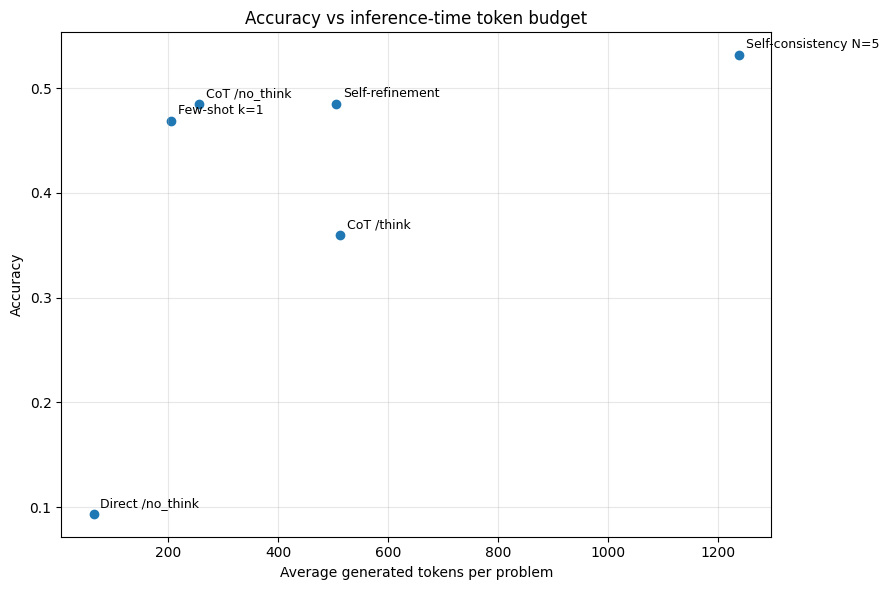

In [14]:
plt.figure(figsize=(9, 6))
plt.scatter(summary_df["avg_generated_tokens"], summary_df["accuracy"])

for _, row in summary_df.iterrows():
    plt.annotate(
        row["method"],
        (row["avg_generated_tokens"], row["accuracy"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9,
    )

plt.xlabel("Average generated tokens per problem")
plt.ylabel("Accuracy")
plt.title("Accuracy vs inference-time token budget")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("accuracy_vs_tokens.png", dpi=150, bbox_inches="tight")
plt.show()

# 14. Short analysis questions

Answer these questions in 300–500 words total.

1. Which method achieved the best accuracy?

   Self-consistancy with N=5.
   
2. Which method was the most efficient in terms of accuracy per generated token?

   CoT /no_think was the most efficient. It hit 48.44% accuracy using very little time (1.72 seconds) and fewer tokens.
3. Did `/think` improve accuracy? Was the extra token budget worth it?


   No-Turning on /think mode dropped accuracy to 35.94%.
   
4. Did self-consistency improve accuracy? What happened to latency?


   Yes it got the best accuracy but it increased latency by 5 times.
   
5. Did few-shot prompting help? Why might the single example help or hurt?


   The single example boosted accuracy to 46.88% by giving the model a clear format to copy.
   
6. Give one failure case. Was it an arithmetic mistake, a reasoning mistake, or an answer-extraction problem?

    Self-refinement failed due to reasoning mistakes. The model is a poor critic; it often looked at a correct answer, imagined an error, and changed it to a wrong one.
    

**Grade: 8 points**
